In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style for professional look
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define path and load the PROCESSED data
base_dir = os.path.dirname(os.getcwd()) # Go up one level from 'notebooks' to the root
processed_data_path = os.path.join(base_dir, 'data', 'processed', 'cleaned_credit_risk.csv')

# Load the dataset
df = pd.read_csv(processed_data_path)

print(f"Data successfully loaded. Shape: {df.shape}")
df.head()

Data successfully loaded. Shape: (32404, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


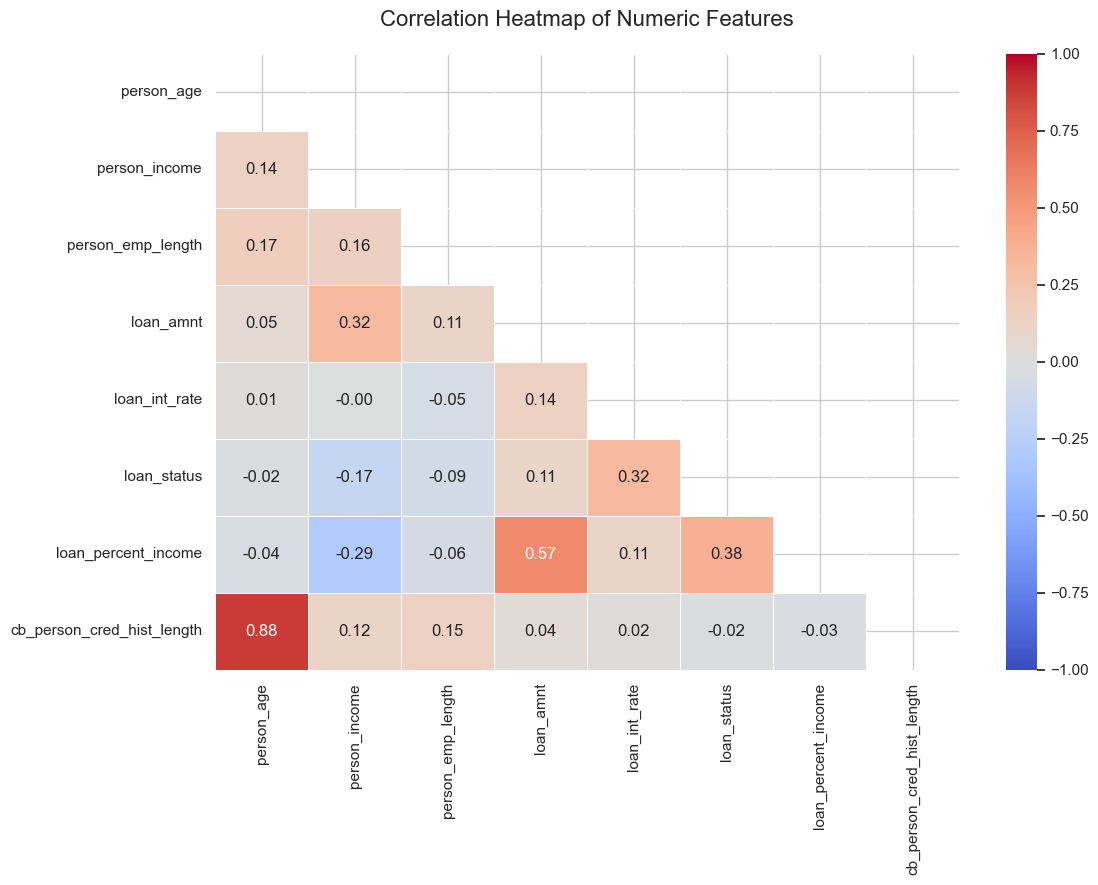

In [3]:
# Isolate numeric columns for correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Create a mask to hide the upper triangle (looks much cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16, pad=20)
plt.show()

Training a lightweight Random Forest for Explainability...


C:\Users\ioann\AppData\Local\Temp\ipykernel_8048\3344148377.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')


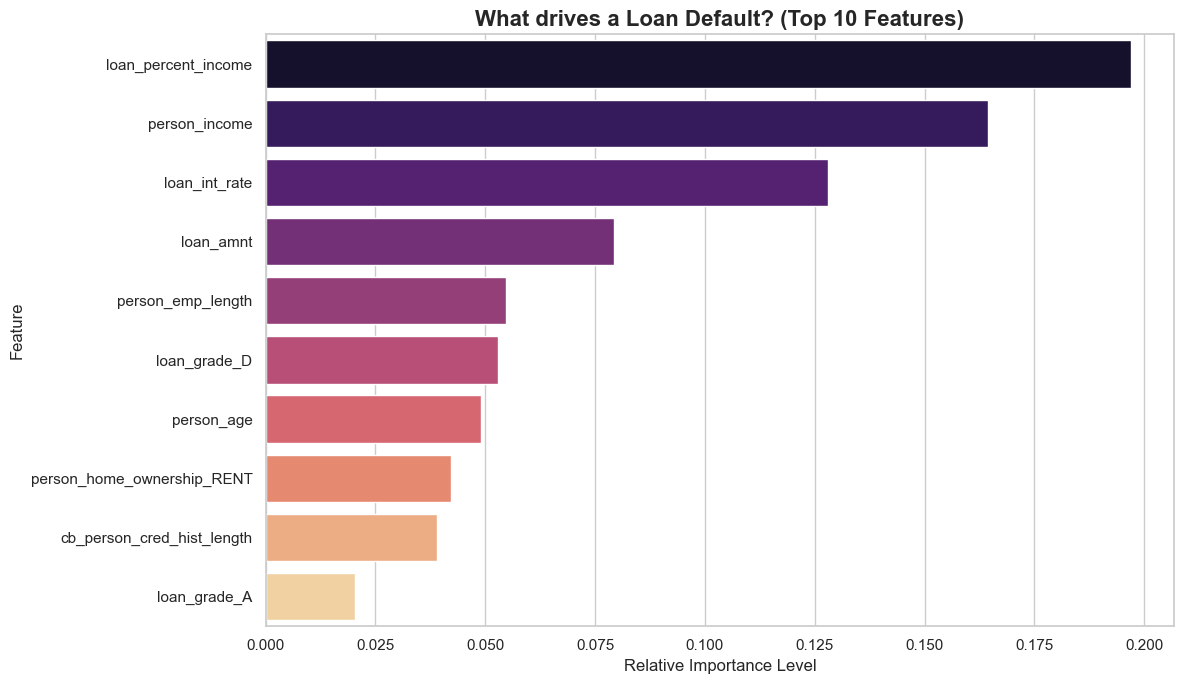

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Training a lightweight Random Forest for Explainability...")

X_viz = df.drop('loan_status', axis=1)
y_viz = df['loan_status']

# Simple encoding for the graph
categorical_cols = X_viz.select_dtypes(include=['object']).columns
X_viz_encoded = pd.get_dummies(X_viz, columns=categorical_cols)

# 2. Fit a quick RF model and find Importance
rf_explainer = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_explainer.fit(X_viz_encoded, y_viz)
importances = rf_explainer.feature_importances_
features = X_viz_encoded.columns

#Short top Features
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
top_10_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

#Plot the Features 
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='magma')
plt.title("What drives a Loan Default? (Top 10 Features)", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance Level", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()